# Example breakdown assessment script for the CUTE tokamak

In [1]:
import os
import sys
import time
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [3]:
tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, create_power_flux_fun

In [4]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    arc_v3a
Revision id:           04589ca
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



In [5]:
mesh_pts,mesh_lc,mesh_reg,coil_dict,cond_dict = load_gs_mesh('CUTE_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict,coil_dict=coil_dict)
mygs.settings.lim_zmax = 0.38 # Prevent limiting in upper/lower divertor areas
mygs.setup(order=2,F0=0.17)


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.301E+00
    # of points  =    5796
    # of edges   =   17283
    # of cells   =   11488
    # of boundary points =     102
    # of boundary edges  =     102
    # of boundary cells  =     102
  Resolution statistics:
    hmin =  3.994E-03
    hrms =  1.721E-02
    hmax =  7.410E-02
  Surface grounded at vertex     761


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    5.0000000000000001E-004


## Coil Limits
For breakdown studies, the coil limits set the maximum availble flux (described below).

In [6]:
coil_bounds = {key: [-1.E3, 1.E3] for key in mygs.coil_sets}
mygs.set_coil_bounds(coil_bounds)

In [7]:
# Set profiles
ffp_prof = create_power_flux_fun(40,1.5,2.0)
pp_prof = create_power_flux_fun(40,4.0,1.0)
mygs.set_profiles(ffp_prof=ffp_prof,pp_prof=pp_prof)

## Compute initial post-breakdown equilibrium

In [8]:
coil_mirrors = {'CS{0:02d}'.format(2*i+1): 'CS{0:02d}'.format(2*i+2) for i in range(7)}
coil_mirrors.update({'PF{0:02d}'.format(i): 'PF{0:02d}'.format(15-i) for i in range(1,8)})
disable_list = ['PF01']

# Set regularization weights
regularization_terms = []
for name, coil in mygs.coil_sets.items():
    if name not in coil_mirrors:
        continue
    if name in disable_list:
        # Set zero target current and high weight on coil and mirror
        regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E5))
        regularization_terms.append(mygs.coil_reg_term({coil_mirrors[name]: 1.0},target=0.0,weight=1.E5))
    else:
        # Set zero target current and small weight to help conditioning of fit
        if name.startswith('CS'):
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=1.E3,weight=1.E-2))
        else:
            regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=0.0,weight=1.E-2))
        # Set zero target for the difference of currents for coil and its mirror to ensure up-down symmetry
        regularization_terms.append(mygs.coil_reg_term({name: 1.0, coil_mirrors[name]: -1.0},target=0.0,weight=1.E0))

# Pass regularization terms to TokaMaker
mygs.set_coil_reg(reg_terms=regularization_terms)

In [9]:
Ip_target = 1.E3
beta_approx = 0.1
mygs.set_targets(Ip=Ip_target,Ip_ratio=(1.0/beta_approx - 1.0))
isoflux_pts = create_isoflux(80,0.2,0.0,0.08,1.0,0.0)
mygs.set_isoflux(isoflux_pts)
mygs.set_saddles(None)

mygs.init_psi(0.2,0.0,0.08,1.0,0.0)
mygs.solve()

coil_currents, _ = mygs.get_coil_currents()

Starting non-linear GS solver
     1  4.8509E-02  3.6569E-02  1.7441E-05  2.0845E-01 -4.8889E-06 -0.0000E+00
     2  5.4935E-02  3.8654E-02  4.0467E-06  2.0778E-01 -2.3793E-06 -0.0000E+00
     3  5.7506E-02  3.9451E-02  1.2647E-06  2.0756E-01 -1.7281E-06 -0.0000E+00
     4  5.8597E-02  3.9771E-02  4.9556E-07  2.0749E-01 -1.5233E-06 -0.0000E+00
 Timing:   3.9657999994233251E-002
   Source:     1.7401999793946743E-002
   Solve:      7.7910001855343580E-003
   Boundary:   1.4919999521225691E-003
   Other:      1.2973000062629580E-002


/var/folders/77/9hnl3h2d5jq7v8mv35f7n_z40000gn/T/ipykernel_43346/24587791.py:5: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_isoflux(isoflux_pts)
/var/folders/77/9hnl3h2d5jq7v8mv35f7n_z40000gn/T/ipykernel_43346/24587791.py:6: DeprecationWarning: `set_saddles()` is deprecated, use `set_saddle_constraints()` instead. This function will be removed in a future version.
  mygs.set_saddles(None)


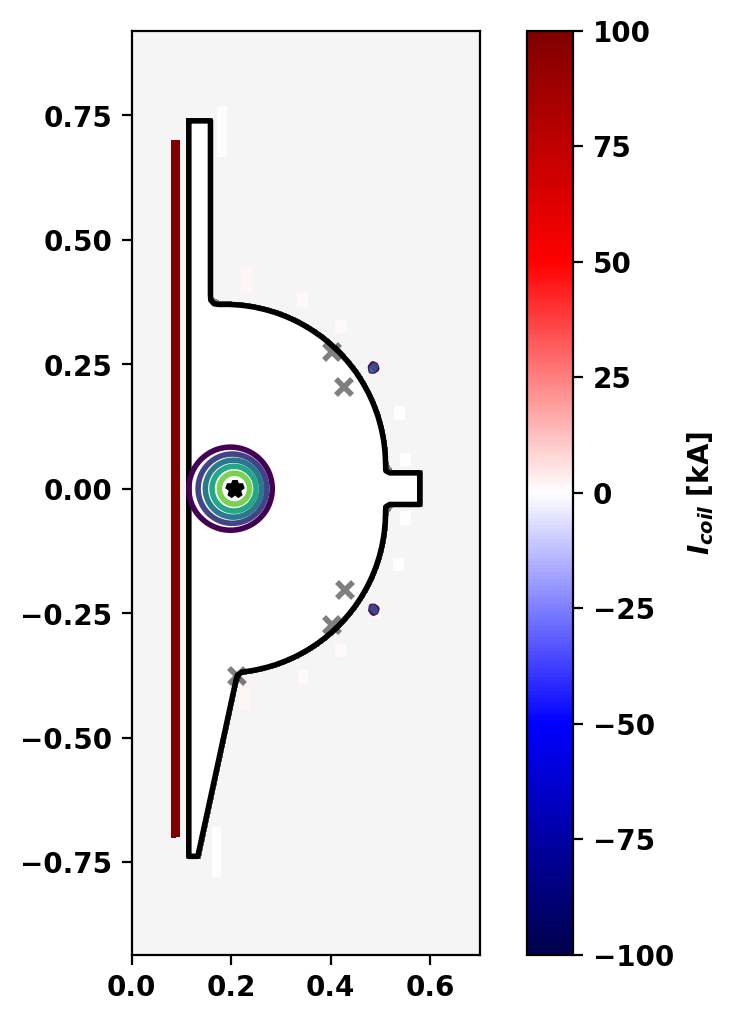

In [10]:
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.0E-3,coil_clabel=r'$I_{coil}$ [kA]')
mygs.plot_psi(fig,ax,xpoint_color='k',vacuum_nlevels=0,plasma_nlevels=6)
# mygs.plot_constraints(fig,ax,isoflux_color='tab:red',isoflux_marker='.')

### We want this value to be as high as possible

$\psi_{LCFS}$ is the poloidal flux on the plasma boundary. The central solenoid (CS) acts as the **primary of a transformer**: its changing flux drives the loop voltage $V_{loop} = -d\psi/dt$ that ionizes the gas and sustains $I_p$. The total volt-second budget for the discharge is the availailible flux swing $\Delta\psi$ between the fully-biased CS state at breakdown and the most negative $\psi$ reachable at the end of the ramp.

The more boundary flux we can establish at breakdown, more flux swing we have availible for the pulse. Effectively this means that we want to bias the CS stack as hard as the coil-current limits allow. Here we scans the CS bias current, re-solve the equilibrium at each value, and keep the bias that gives the largest $\psi_{LCFS}$ (then re-solves there so the rest of the notebook uses that state).

/var/folders/77/9hnl3h2d5jq7v8mv35f7n_z40000gn/T/ipykernel_43346/988288092.py:24: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_isoflux(isoflux_pts)
/var/folders/77/9hnl3h2d5jq7v8mv35f7n_z40000gn/T/ipykernel_43346/988288092.py:25: DeprecationWarning: `set_saddles()` is deprecated, use `set_saddle_constraints()` instead. This function will be removed in a future version.
  mygs.set_saddles(None)


Starting non-linear GS solver
     1  4.8418E-02  3.6506E-02  1.5653E-05  2.0844E-01 -9.9305E-06 -0.0000E+00
     2  5.4828E-02  3.8589E-02  4.2606E-06  2.0777E-01 -7.5875E-06 -0.0000E+00
     3  5.7395E-02  3.9384E-02  1.3790E-06  2.0755E-01 -7.0146E-06 -0.0000E+00
     4  5.8483E-02  3.9704E-02  5.1992E-07  2.0747E-01 -6.8365E-06 -0.0000E+00
 Timing:   3.6946000065654516E-002
   Source:     1.5509000048041344E-002
   Solve:      7.6729997526854277E-003
   Boundary:   9.9299987778067589E-004
   Other:      1.2771000387147069E-002
Starting non-linear GS solver
     1  4.8431E-02  3.6515E-02  1.5904E-05  2.0844E-01 -9.2441E-06 -0.0000E+00
     2  5.4843E-02  3.8598E-02  4.2324E-06  2.0777E-01 -6.8762E-06 -0.0000E+00
     3  5.7410E-02  3.9393E-02  1.3613E-06  2.0755E-01 -6.2918E-06 -0.0000E+00
     4  5.8499E-02  3.9714E-02  5.1522E-07  2.0747E-01 -6.1098E-06 -0.0000E+00
 Timing:   3.5758000100031495E-002
   Source:     1.4989999821409583E-002
   Solve:      7.0539999287575483E-003
   B

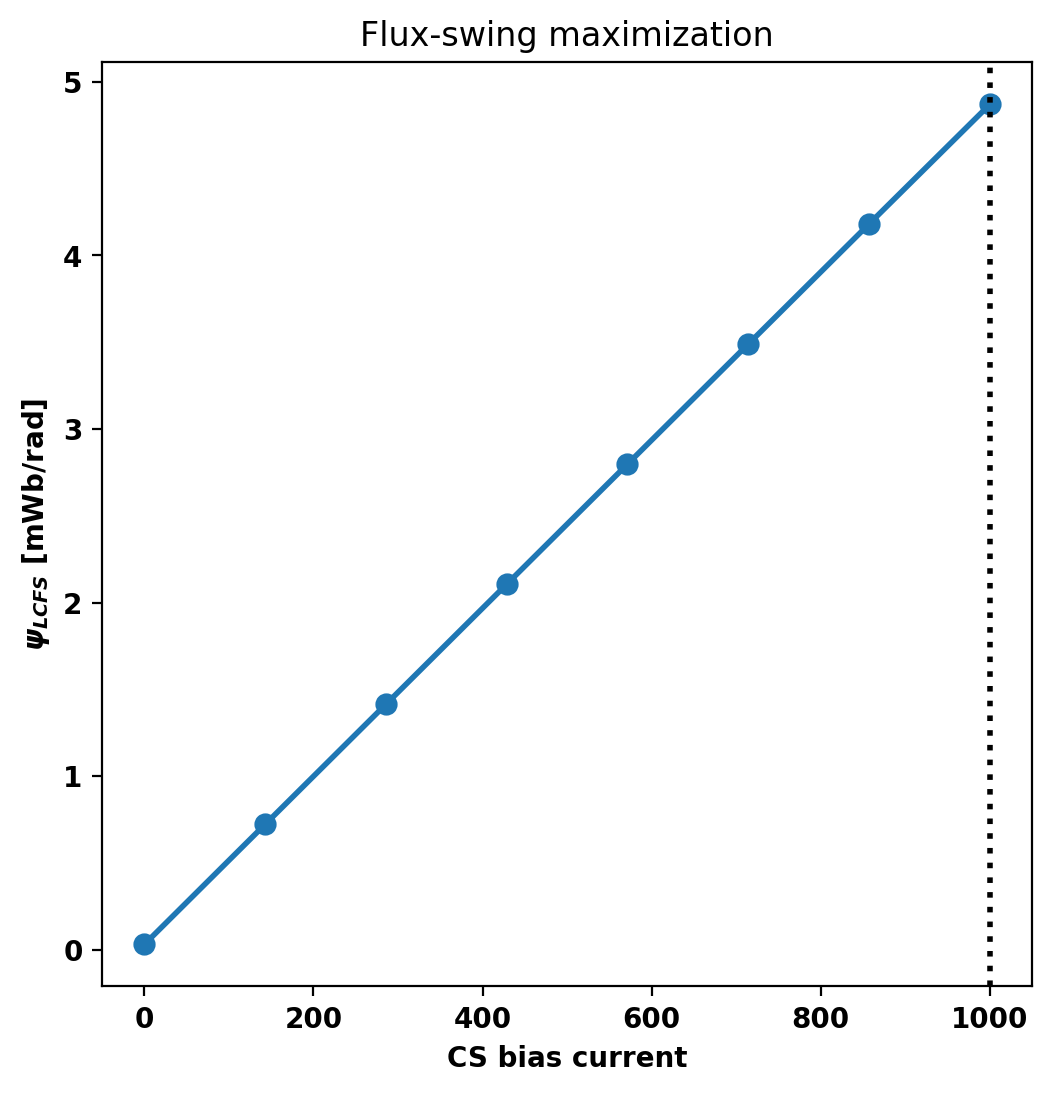

In [11]:
# --- Maximize the available flux swing ---------------------------------------
# Bias the CS stack harder to store more poloidal flux (higher psi_LCFS = bigger
# volt-second budget). We scan the CS bias current, re-solve the equilibrium at
# each value, and keep the bias that maximizes psi_LCFS within the coil bounds.
cs_coils = [k for k in mygs.coil_sets if k.startswith('CS')]
cs_bound = coil_bounds[cs_coils[0]][1]      # per-coil current limit set above

def solve_with_cs_bias(cs_target):
    """Re-solve the post-breakdown equilibrium with the CS biased to cs_target."""
    reg = []
    for name, coil in mygs.coil_sets.items():
        if name not in coil_mirrors:
            continue
        if name in disable_list:
            reg.append(mygs.coil_reg_term({name: 1.0}, target=0.0, weight=1.E5))
            reg.append(mygs.coil_reg_term({coil_mirrors[name]: 1.0}, target=0.0, weight=1.E5))
        else:
            tgt = cs_target if name.startswith('CS') else 0.0
            reg.append(mygs.coil_reg_term({name: 1.0}, target=tgt, weight=1.E-2))
            reg.append(mygs.coil_reg_term({name: 1.0, coil_mirrors[name]: -1.0},
                                          target=0.0, weight=1.E0))
    mygs.set_coil_reg(reg_terms=reg)
    mygs.set_targets(Ip=Ip_target, Ip_ratio=(1.0/beta_approx - 1.0))
    mygs.set_isoflux(isoflux_pts)
    mygs.set_saddles(None)
    mygs.init_psi(0.2, 0.0, 0.08, 1.0, 0.0)
    mygs.solve()
    return mygs.psi_bounds[0]

cs_scan  = np.linspace(0.0, cs_bound, 8)
psi_scan = np.array([solve_with_cs_bias(t) for t in cs_scan])
ibest    = int(np.argmax(psi_scan))
print('psi_LCFS:  zero-bias = {0:10.3E}   maximized = {1:10.3E} [mWb/rad]'.format(
      psi_scan[0]*1.E3, psi_scan[ibest]*1.E3))
print('best CS bias current = {0:10.3E}'.format(cs_scan[ibest]))

# Re-solve at the best bias so downstream cells use the maximized equilibrium
solve_with_cs_bias(cs_scan[ibest])
coil_currents, _ = mygs.get_coil_currents()

fig, ax = plt.subplots(1, 1)
ax.plot(cs_scan, psi_scan*1.E3, 'o-')
ax.axvline(cs_scan[ibest], color='k', ls=':')
ax.set_xlabel('CS bias current'); ax.set_ylabel(r'$\psi_{LCFS}$ [mWb/rad]')
_ = ax.set_title('Flux-swing maximization')

## Compute coils for vacuum null

In [12]:
# Set regularization weights
regularization_terms = []
for name, coil in mygs.coil_sets.items():
    regularization_terms.append(mygs.coil_reg_term({name: 1.0},target=coil_currents[name],weight=1.E1))

# Pass regularization terms to TokaMaker
mygs.set_coil_reg(reg_terms=regularization_terms)

In [13]:
mygs.set_targets()
mygs.set_isoflux(None)
zero_field_pts = np.array([
    [0.2,0.0],
    [0.25,0.0],
    [0.15,0.0],
    [0.2,0.05],
    [0.2,-0.05]
])
mygs.set_saddles(zero_field_pts)
mygs.solve(vacuum=True)

null_coil_currents, _ = mygs.get_coil_currents()

Starting non-linear GS solver
     1  5.8597E-02  3.9771E-02  3.5791E-05  2.0552E-01  1.6438E-05 -0.0000E+00
     2  5.8597E-02  3.9771E-02  7.1582E-06  1.8841E-01  3.1520E-05 -0.0000E+00
     3  5.8597E-02  3.9771E-02  1.4316E-06  5.0000E-01  0.0000E+00 -0.0000E+00
     4  5.8597E-02  3.9771E-02  2.8633E-07  5.0000E-01  0.0000E+00 -0.0000E+00
 Timing:   2.7138999896124005E-002
   Source:     0.0000000000000000     
   Solve:      9.1380001977086067E-003
   Boundary:   0.0000000000000000     
   Other:      1.8000999698415399E-002


/var/folders/77/9hnl3h2d5jq7v8mv35f7n_z40000gn/T/ipykernel_43346/498142008.py:2: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_isoflux(None)
/var/folders/77/9hnl3h2d5jq7v8mv35f7n_z40000gn/T/ipykernel_43346/498142008.py:10: DeprecationWarning: `set_saddles()` is deprecated, use `set_saddle_constraints()` instead. This function will be removed in a future version.
  mygs.set_saddles(zero_field_pts)


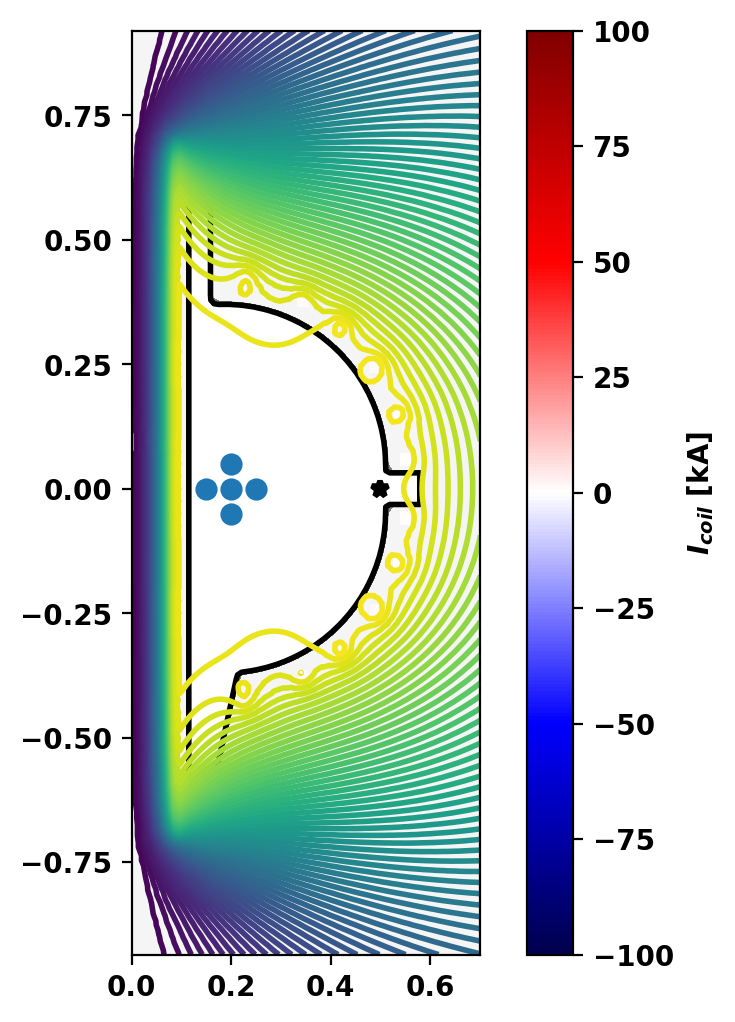

In [14]:
fig, ax = plt.subplots(1,1)
mygs.plot_machine(fig,ax,coil_colormap='seismic',coil_symmap=True,coil_scale=1.0E-3,coil_clabel=r'$I_{coil}$ [kA]')
mygs.plot_psi(fig,ax,normalized=False,xpoint_color=None,vacuum_nlevels=0,plasma_nlevels=60)
mygs.plot_constraints(fig,ax,saddle_color='tab:blue',saddle_marker='o')

### We want these values to be below some threshold

These are the residual poloidal field magnitudes $|B_{pol}|$ at the constraint points in the null region. They set the **connection length** $L_c \propto B_\phi/|B_{pol}|$ — how far a freshly-ionized electron streams along the (nearly toroidal) field before drifting into a wall. A long connection length lets electrons circulate many times and ionize enough neutral gas to start the Townsend avalanche; a stray field that is too large short-circuits that and breakdown fails.

So a good null must stay **below a threshold** at *every* point in the region, typically $|B_{pol}| \lesssim 1$–$2$ mT (10–20 G). The cell below sets that threshold explicitly, checks each constraint point against it, prints a pass/fail per point, and outlines any violating point in red. 

Null-field threshold check  (B_threshold = 2.00 mT):
  pt 0  R=0.200  Z=+0.000   |B_pol| =  0.045 mT   ok
  pt 1  R=0.250  Z=+0.000   |B_pol| =  0.026 mT   ok
  pt 2  R=0.150  Z=+0.000   |B_pol| =  0.107 mT   ok
  pt 3  R=0.200  Z=+0.050   |B_pol| =  0.101 mT   ok
  pt 4  R=0.200  Z=-0.050   |B_pol| =  0.101 mT   ok
=> ALL POINTS PASS


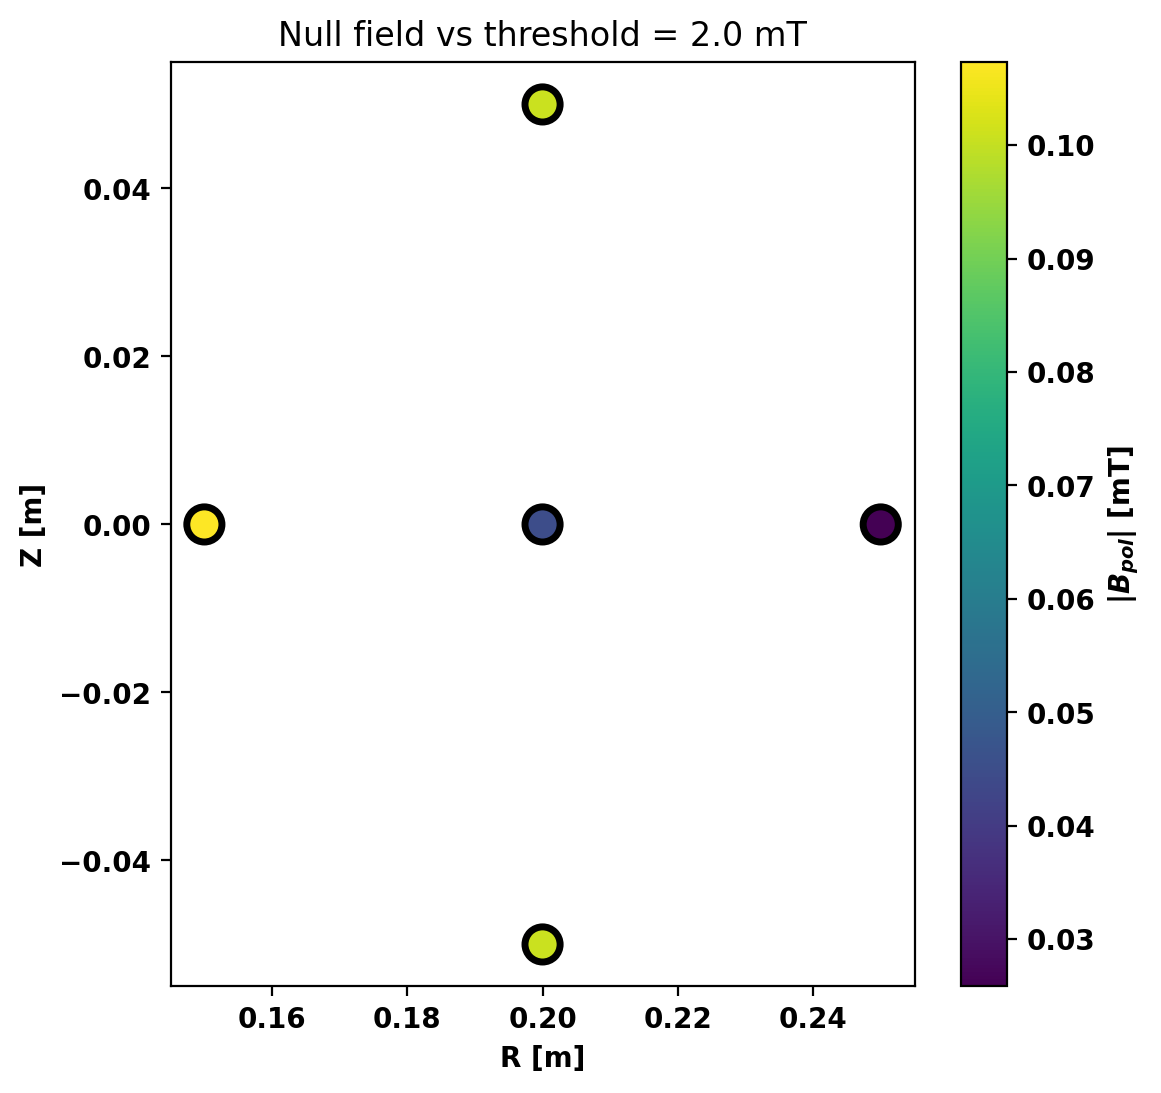

In [15]:
# --- Threshold check on the null field ---------------------------------------
B_THRESHOLD = 2.0E-3      # max acceptable |B_pol| in the null region [T]  (~20 G)

field_eval = mygs.get_field_eval('B')
Bp = []
for i in range(zero_field_pts.shape[0]):
    B_tmp = field_eval.eval(zero_field_pts[i, :])
    Bp.append(np.linalg.norm(B_tmp[[0, 2]]))
Bp = np.array(Bp)

passes = Bp <= B_THRESHOLD
print('Null-field threshold check  (B_threshold = {0:.2f} mT):'.format(B_THRESHOLD*1.E3))
for i, (pt, b, ok) in enumerate(zip(zero_field_pts, Bp, passes)):
    print('  pt {0}  R={1:.3f}  Z={2:+.3f}   |B_pol| = {3:6.3f} mT   {4}'.format(
          i, pt[0], pt[1], b*1.E3, 'ok' if ok else 'ABOVE THRESHOLD'))
print('=> ' + ('ALL POINTS PASS' if passes.all() else 'SOME POINTS EXCEED THRESHOLD'))

fig, ax = plt.subplots(1, 1)
clf = ax.scatter(zero_field_pts[:, 0], zero_field_pts[:, 1], c=Bp*1.E3, marker='o',
                 s=160, cmap='viridis',
                 edgecolors=['k' if ok else 'red' for ok in passes], linewidths=2.5)
cb = fig.colorbar(clf); cb.set_label(r'$|B_{pol}|$ [mT]')
ax.set_xlabel('R [m]'); ax.set_ylabel('Z [m]')
_ = ax.set_title('Null field vs threshold = {0:.1f} mT'.format(B_THRESHOLD*1.E3))

In [16]:
print("Coil current change null -> plasma")
for key in coil_currents:
    print('  {0} {1:12.3E}'.format(key, coil_currents[key]-null_coil_currents[key]))

Coil current change null -> plasma
  CS01   -4.246E-04
  CS02    0.000E+00
  CS03   -8.087E-04
  CS04    0.000E+00
  CS05   -1.712E-03
  CS06    0.000E+00
  CS07   -4.132E-03
  CS08    0.000E+00
  CS09   -5.844E-01
  CS10   -5.852E-01
  CS11   -5.274E-01
  CS12   -5.302E-01
  CS13    2.060E+00
  CS14    2.064E+00
  PF01   -2.243E-01
  PF02   -1.207E+00
  PF03   -1.181E+00
  PF04   -1.624E+00
  PF05   -2.057E+00
  PF06   -2.340E+00
  PF07   -2.516E+00
  PF08   -2.519E+00
  PF09   -2.346E+00
  PF10   -2.057E+00
  PF11   -1.627E+00
  PF12   -1.191E+00
  PF13   -1.185E+00
  PF14   -1.923E-01


## Breakdown physics: will the gas actually break down?
A small $|B_{pol}|$ at the null is *necessary* but not *sufficient*. Whether the prefilled gas avalanches into a plasma depends on two more things:

- **Connection length** $L_c \approx 0.25\,a\,B_\phi/B_{pol}$ — how far an ionized electron travels along the nearly-toroidal field before drifting to a wall. A small null field gives a long $L_c$.
- **Townsend avalanche** — driven by the toroidal loop-voltage field $E_\phi$. For hydrogen the electron density grows as $e^{\alpha L_c}$ with $\alpha = A\,p\,e^{-Bp/E}$ ($A=510\ \mathrm{m^{-1}Pa^{-1}}$, $B=1.25\times10^4\ \mathrm{V\,m^{-1}Pa^{-1}}$). Requiring at least one e-folding, $\alpha L_c \ge 1$, sets a **minimum E-field** (a Paschen-type curve):
$$E_{min}(p) = \frac{B\,p}{\ln(A\,p\,L_c)}.$$

Breakdown succeeds when the available $E_\phi = V_{loop}/(2\pi R)$ clears $E_{min}$ for some prefill pressure near the Paschen minimum.

max |B_pol| at null = 0.11 mT  ->  connection length L_c = 158 m
Paschen E_min = 6.20 V/m at p = 0.020 mTorr   (available 10.0 V/m)
=> BREAKS DOWN


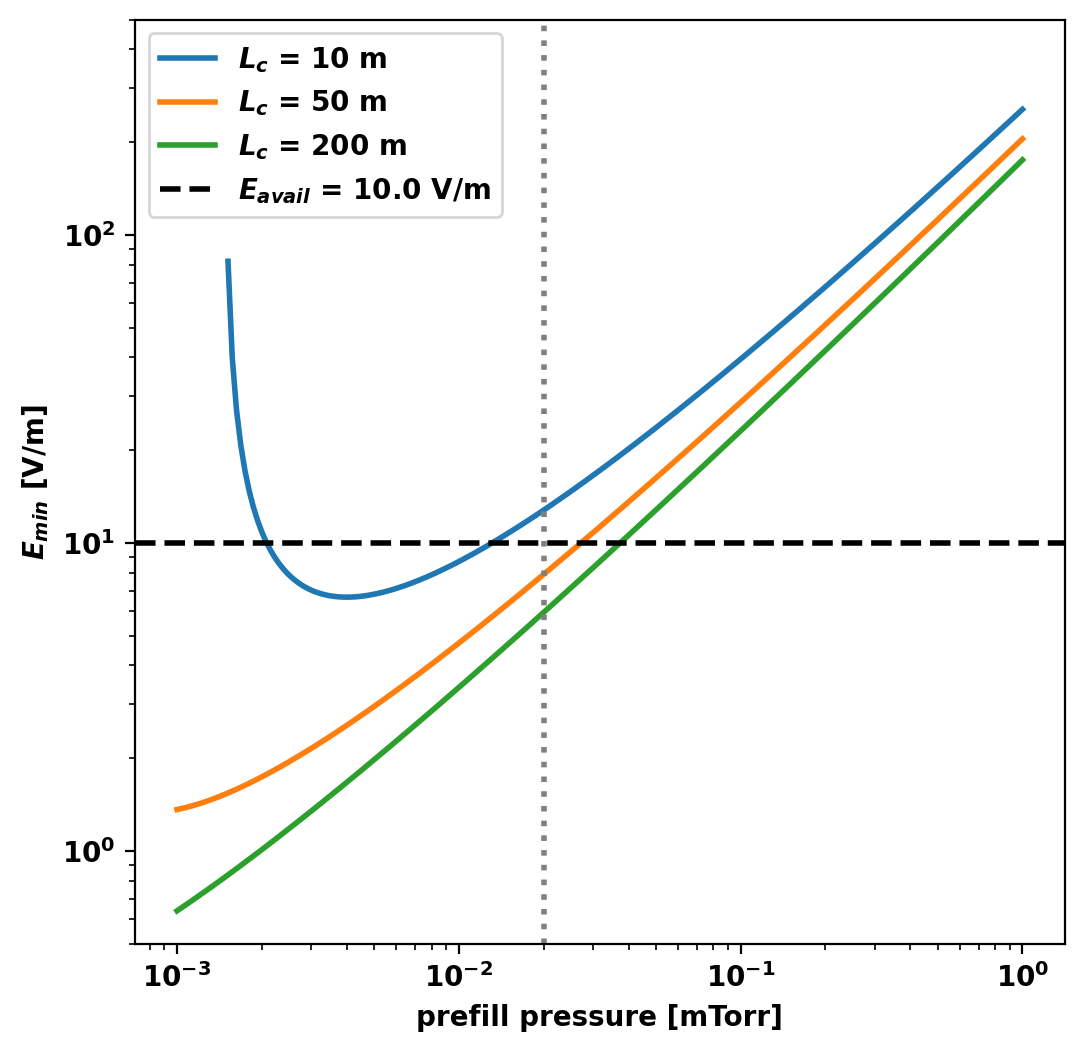

In [17]:
# --- Townsend / Paschen breakdown physics for hydrogen (Lloyd et al.) ---
TOWNSEND_A = 510.0      # m^-1 Pa^-1
TOWNSEND_B = 1.25e4     # V m^-1 Pa^-1
TORR_TO_PA = 133.322
F0_CUTE    = 0.17       # R*B_phi [T*m]  (matches the F0 passed to mygs.setup)
a_null     = 0.08       # size of the low-field region ~ minor radius [m]

def connection_length(B_pol, R, a=a_null):
    """Effective connection length L_c ~ 0.25 a (B_phi/B_pol)  [m]."""
    Bphi = F0_CUTE / R
    return 0.25 * a * abs(Bphi) / max(float(B_pol), 1e-9)

def paschen_Emin(p_pa, L_c):
    """Minimum toroidal E-field for avalanche (alpha*L_c >= 1)  [V/m]."""
    arg = TOWNSEND_A * p_pa * L_c
    return np.inf if arg <= 1.0 else TOWNSEND_B * p_pa / np.log(arg)

# --- Operating point at the null we just solved (uses Bp from the cell above) ---
# These two are device-dependent; set E_avail = V_loop / (2*pi*R) from your OH ramp.
prefill_torr = 2.0e-5   # hydrogen prefill near the Paschen minimum [Torr]
E_avail      = 10.0     # toroidal E-field available from the OH ramp [V/m]

Bp_null = Bp.max()
L_c     = connection_length(Bp_null, 0.2)
E_min   = paschen_Emin(prefill_torr * TORR_TO_PA, L_c)
print('max |B_pol| at null = {0:.2f} mT  ->  connection length L_c = {1:.0f} m'.format(
      Bp_null*1e3, L_c))
print('Paschen E_min = {0:.2f} V/m at p = {1:.3f} mTorr   (available {2:.1f} V/m)'.format(
      E_min, prefill_torr*1e3, E_avail))
print('=> ' + ('BREAKS DOWN' if E_avail >= E_min else 'NO breakdown: lower |B_pol| or raise E'))

# --- Paschen curve: minimum E vs prefill pressure for a few connection lengths ---
p = np.logspace(-6, -3, 200)
fig, ax = plt.subplots(1, 1)
for Lc in [10, 50, 200]:
    ax.plot(p*1e3, [paschen_Emin(pp*TORR_TO_PA, Lc) for pp in p], label='$L_c$ = {0} m'.format(Lc))
ax.axhline(E_avail, color='k', ls='--', label='$E_{{avail}}$ = {0} V/m'.format(E_avail))
ax.axvline(prefill_torr*1e3, color='grey', ls=':')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_ylim(0.5, 500)
ax.set_xlabel('prefill pressure [mTorr]'); ax.set_ylabel('$E_{min}$ [V/m]')
_ = ax.legend()

## Optimizing the null location
The solver already finds the *coil currents* that null the field at the points we ask for. The remaining design freedom is **where** to put the null. Below we sweep the null center in $R$ and re-solve, looking for the location where the coils make the smallest residual $|B_{pol}|$ (and hence the longest connection length). This is a minimal 1-D version of the $(R,Z)$ grid-scan + refinement used in production breakdown-design scripts.

Starting non-linear GS solver
     1  5.8597E-02  3.9771E-02  4.3088E-06  5.0000E-01  0.0000E+00 -0.0000E+00
     2  5.8597E-02  3.9771E-02  8.6175E-07  5.0000E-01  0.0000E+00 -0.0000E+00
 Timing:   1.0502999881282449E-002
   Source:     0.0000000000000000     
   Solve:      3.4139999188482761E-003
   Boundary:   0.0000000000000000     
   Other:      7.0889999624341726E-003
Starting non-linear GS solver
     1  5.8597E-02  3.9771E-02  1.8125E-06  5.0000E-01  0.0000E+00 -0.0000E+00
     2  5.8597E-02  3.9771E-02  3.6250E-07  5.0000E-01  0.0000E+00 -0.0000E+00
 Timing:   1.0197000112384558E-002
   Source:     0.0000000000000000     
   Solve:      3.4380001015961170E-003
   Boundary:   0.0000000000000000     
   Other:      6.7590000107884407E-003
Starting non-linear GS solver
     1  5.8597E-02  3.9771E-02  8.4874E-07  5.0000E-01  0.0000E+00 -0.0000E+00
 Timing:   5.7519997935742140E-003
   Source:     0.0000000000000000     
   Solve:      1.6989998985081911E-003
   Boundary:   0.000

/var/folders/77/9hnl3h2d5jq7v8mv35f7n_z40000gn/T/ipykernel_43346/7961170.py:11: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_isoflux(None)
/var/folders/77/9hnl3h2d5jq7v8mv35f7n_z40000gn/T/ipykernel_43346/7961170.py:12: DeprecationWarning: `set_saddles()` is deprecated, use `set_saddle_constraints()` instead. This function will be removed in a future version.
  mygs.set_saddles(stencil)
/var/folders/77/9hnl3h2d5jq7v8mv35f7n_z40000gn/T/ipykernel_43346/7961170.py:33: DeprecationWarning: `set_isoflux()` is deprecated, use `set_isoflux_constraints()` instead. This function will be removed in a future version.
  mygs.set_targets(); mygs.set_isoflux(None)
/var/folders/77/9hnl3h2d5jq7v8mv35f7n_z40000gn/T/ipykernel_43346/7961170.py:34: DeprecationWarning: `set_saddles()` is deprecated, use `set_saddle_constraints()` instead. This function will be removed in a future version.
  mygs.set_s

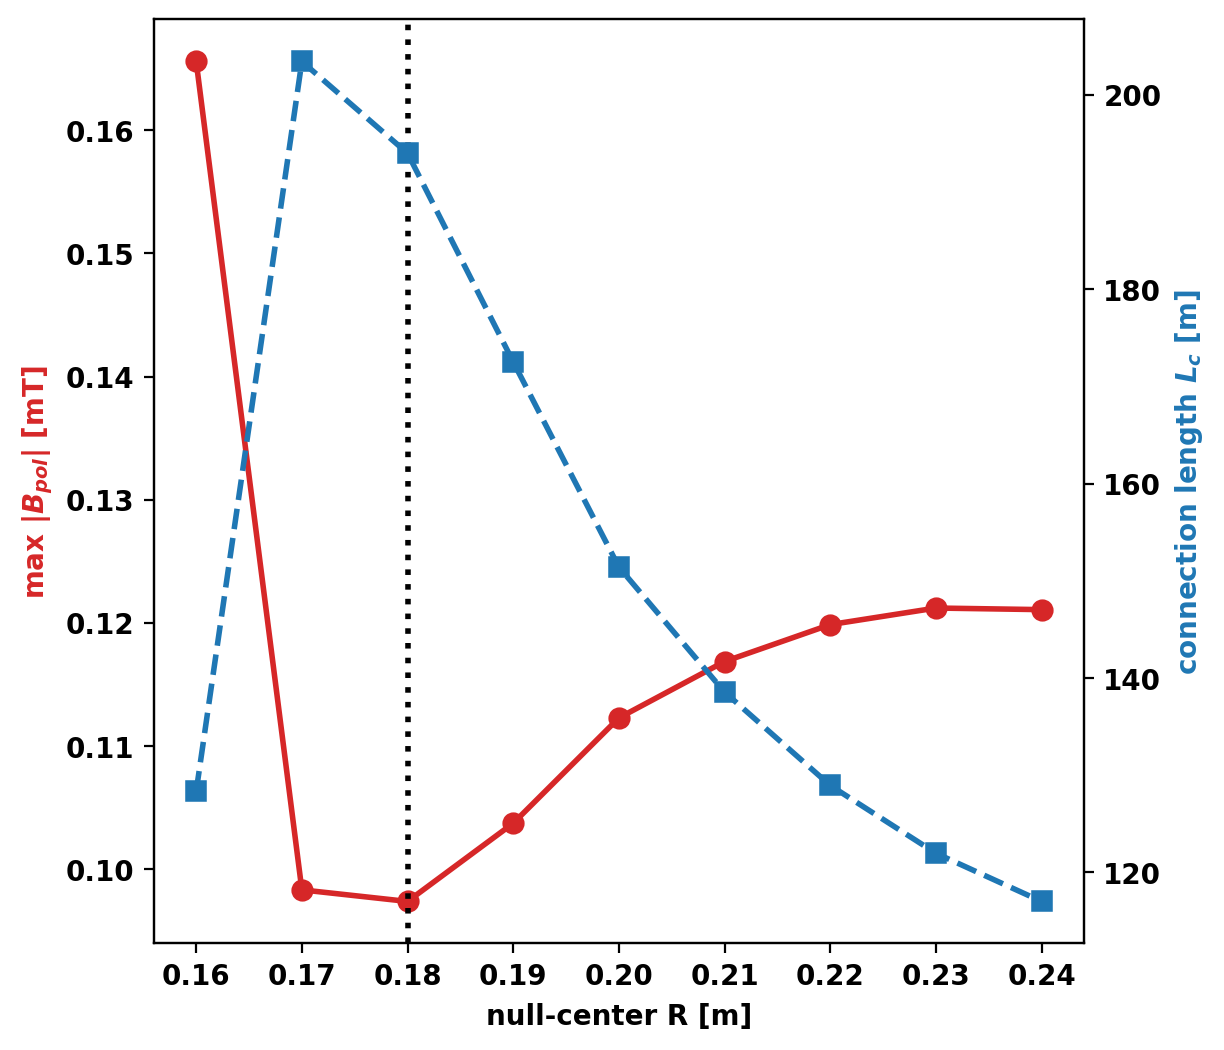

In [18]:
# Scan the null location: where can the coils make the cleanest null?
# (Re-solve the vacuum null with the stencil centered at a range of R; the coil
#  regularization target is kept fixed from the plasma solve above — a simple,
#  pedagogical 1-D version of the (R,Z) optimization done in production scripts.)
R_scan = np.linspace(0.16, 0.24, 9)
bpmax_scan, Lc_scan = [], []
for R0n in R_scan:
    stencil = np.array([[R0n, 0.0], [R0n+0.05, 0.0], [R0n-0.05, 0.0],
                        [R0n, 0.05], [R0n, -0.05]])
    mygs.set_targets()
    mygs.set_isoflux(None)
    mygs.set_saddles(stencil)
    mygs.solve(vacuum=True)
    fe = mygs.get_field_eval('B')
    bp = np.array([np.linalg.norm(fe.eval(p)[[0, 2]]) for p in stencil])
    bpmax_scan.append(bp.max())
    Lc_scan.append(connection_length(bp.max(), R0n))
bpmax_scan, Lc_scan = np.array(bpmax_scan), np.array(Lc_scan)
ibest = int(np.argmin(bpmax_scan))

fig, ax1 = plt.subplots(1, 1)
ax1.plot(R_scan, bpmax_scan*1e3, 'o-', color='tab:red')
ax1.set_xlabel('null-center R [m]')
ax1.set_ylabel(r'max $|B_{pol}|$ [mT]', color='tab:red')
ax2 = ax1.twinx()
ax2.plot(R_scan, Lc_scan, 's--', color='tab:blue')
ax2.set_ylabel(r'connection length $L_c$ [m]', color='tab:blue')
ax1.axvline(R_scan[ibest], color='k', ls=':')
print('Cleanest null at R = {0:.3f} m:  |B_pol| = {1:.2f} mT,  L_c = {2:.0f} m'.format(
      R_scan[ibest], bpmax_scan[ibest]*1e3, Lc_scan[ibest]))

# Restore the original null so later cells see the baseline state
mygs.set_targets(); mygs.set_isoflux(None)
mygs.set_saddles(zero_field_pts); mygs.solve(vacuum=True)

## The Leuer breakdown criterion: $E_\phi B_\phi / B_\perp$ 

The connection-length picture above has a compact engineering form that is often applied in the tokamak-startup community (from Leuer, J. A., et al. "Plasma startup design of fully superconducting tokamaks EAST and KSTAR with implications for ITER." IEEE transactions on plasma science 38.3 (2010): 333-340). Two experimentally-calibrated conditions must hold in the breakdown region:

$$E_\phi \ge 0.3\ \mathrm{V/m\ (ohmic)},\qquad E_\phi \ge 0.15\ \mathrm{V/m\ (ECRF\text{-}assisted)} \tag{1}$$
$$\frac{E_\phi\, B_\phi}{B_\perp} \ge 10^3\ \mathrm{V/m} \tag{2}$$

where $E_\phi$ is the toroidal electric field (loop voltage $V_{loop} = E_\phi\,2\pi R$), $B_\phi$ the toroidal field, and $B_\perp$ the **average** stray poloidal field over the breakdown region. Criterion (2) is essentially $E_\phi$ times the normalized connection length, since $B_\phi/B_\perp \propto L_c/a$. It rewards *both* a strong loop voltage and a clean null at once. Let's evaluate both criteria at our null and shows how clean the null must be to pass (2).

Breakdown region:   B_phi = 0.850 T    B_perp = 0.076 mT
(1) E_phi floor:    0.30 V/m  (have 0.50)        -> OK
(2) E_phi*B_phi/B_perp =    5604 V/m  (>= 1000 V/m)  -> OK
    V_loop = 0.63 V    minimum E_phi for breakdown = 0.30 V/m


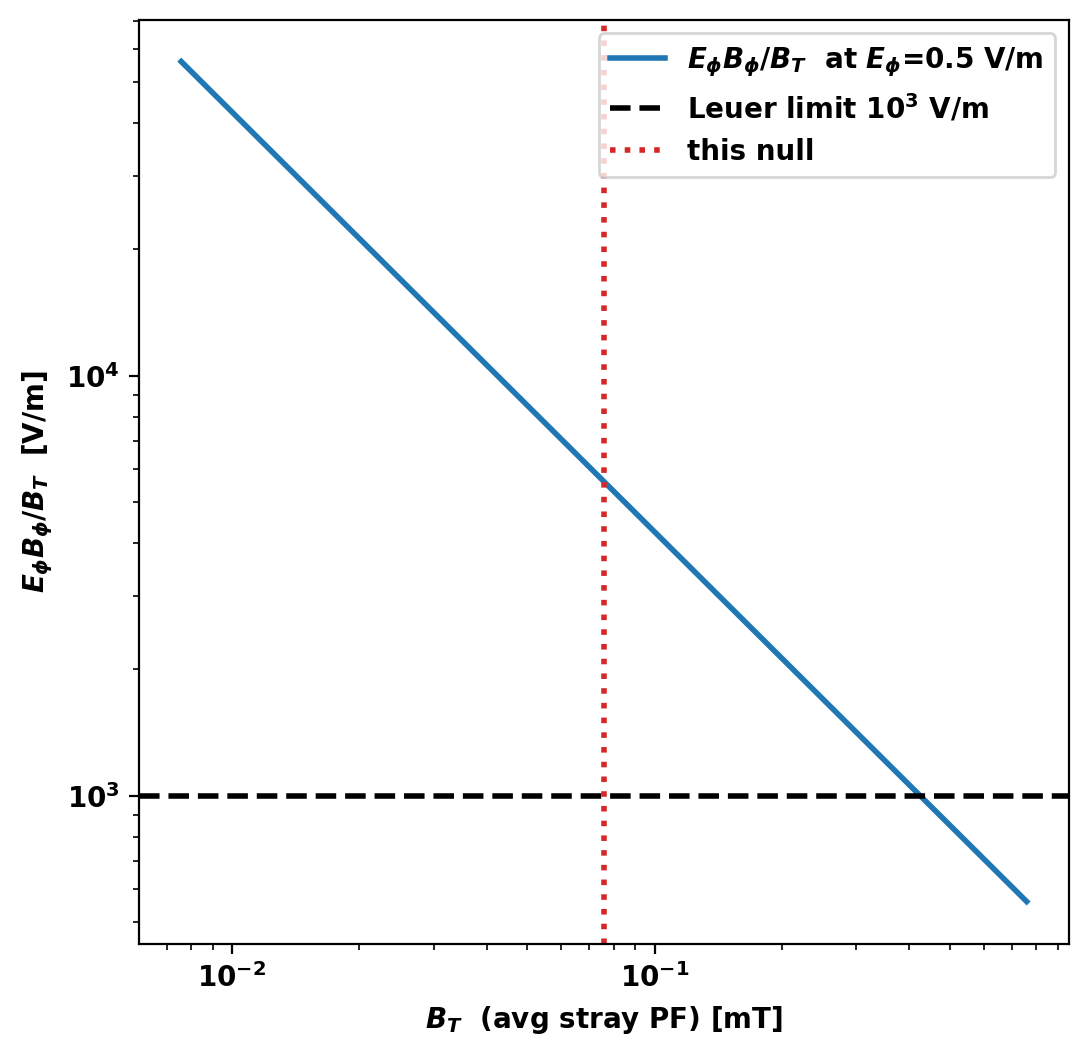

In [22]:
# --- Leuer / ITER breakdown criteria  ("Etanga" = E_phi * B_phi / B_perp) -----
E_phi       = 0.5      # available toroidal E-field at the null [V/m] (set from OH ramp)
ECRF_assist = False    # True lowers the ohmic floor from 0.3 to 0.15 V/m

R_null = 0.2
B_phi  = F0_CUTE / R_null            # toroidal field at the null [T]
B_perp = Bp.mean()                   # AVERAGE stray poloidal field over null region [T]
V_loop = E_phi * 2*np.pi * R_null    # loop voltage [V]

E_floor   = 0.15 if ECRF_assist else 0.30
etanga    = E_phi * B_phi / B_perp                  # criterion (2) figure of merit [V/m]
E_phi_req = max(E_floor, 1.0e3 * B_perp / B_phi)    # min E_phi to satisfy BOTH criteria

print('Breakdown region:   B_phi = {0:.3f} T    B_perp = {1:.3f} mT'.format(B_phi, B_perp*1.E3))
print('(1) E_phi floor:    {0:.2f} V/m  (have {1:.2f})        -> {2}'.format(
      E_floor, E_phi, 'OK' if E_phi >= E_floor else 'FAIL'))
print('(2) E_phi*B_phi/B_perp = {0:7.0f} V/m  (>= 1000 V/m)  -> {1}'.format(
      etanga, 'OK' if etanga >= 1.0E3 else 'FAIL'))
print('    V_loop = {0:.2f} V    minimum E_phi for breakdown = {1:.2f} V/m'.format(V_loop, E_phi_req))

# Sensitivity / design target: how clean must the null (B_perp) be to pass (2)?
Bperp_scan = np.logspace(np.log10(B_perp/10), np.log10(B_perp*10), 100)
fig, ax = plt.subplots(1, 1)
ax.loglog(Bperp_scan*1.E3, E_phi*B_phi/Bperp_scan,
          label=r'$E_\phi B_\phi/B_T$  at $E_\phi$={0} V/m'.format(E_phi))
ax.axhline(1.E3, color='k', ls='--', label=r'Leuer limit $10^3$ V/m')
ax.axvline(B_perp*1.E3, color='tab:red', ls=':', label='this null')
ax.set_xlabel(r'$B_T$  (avg stray PF) [mT]'); ax.set_ylabel(r'$E_\phi B_\phi/B_T$  [V/m]')
_ = ax.legend()